# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from keras_tuner import RandomSearch
from tensorflow.keras import  mixed_precision, layers
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from pathlib import Path
from datetime import datetime
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from keras import activations

# Goal

# Exploration du momentum sur les actions américaines

## 
Dans ce notebook, nous allons explorer le phénomène du momentum sur les actions américaines. On a observer au travers de précédentes recherches qu'il existe des combinaisons de paramètres qui permettent d'obtenir un ratio de Sharpe élevé.
Ces paramètres sont : 
- détenir 5 actions
- choisir les actions avec la plus forte croissance sur une période des 6 mois derniers mois
- Changer d'actions tous les 3 mois
- Vendre l'action si la moyenne mobile 12 périodes est inférieure à la moyenne mobile 50 périodes (weekly)
- Performance : Supérieur à 20% 

Problèmes à résoudre : 
- Drawdown élevé: pouvant atteindre 45%
- Améliorer la performance

## Objectif

Le but de ce notebook est de trouver un modèle de reseaux de neurones qui permettent d'améliorer la performance et de réduire le drawdown du portefeuille précédent.

## Données

Nous allons utiliser un dataset du portefeuille précédent, c'est à dire que nous allons utiliser les données des actions américaines depuis le 1er janvier 2000 avec des features toutes les 3 mois pour respecter le changement d'actions tous les 3 mois.
En features, nous allons utiliser les features suivantes : perf 1 an, 6 mois, 3 mois, 1 mois, moyenne mobile 12, 25, 50 periode hebdomadaire.

## Modèle

Nous allons utiliser un modèle de reseaux de neurones pour prédire les actions à acheter et à vendre.
Le modele devra prédire les actions à acheter et à vendre pour les 3 prochains mois. Donc prédire la performance future dans les 3 prochains mois.
On va utiliser un modèle de reseaux de neurones MLP pour ce probleme de regression.

# Data


In [2]:

daily_data = pd.DataFrame()
data_SP500 = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_SP500.parquet')
data_NDX = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_NASDAQ.parquet')
daily_data = pd.concat([data_SP500, data_NDX], ignore_index=True)
daily_data = daily_data.drop_duplicates(subset=['Ticker', 'Date'])
daily_data = daily_data.drop(columns='Adj Close')
daily_data


Price,Date,Close,High,Low,Open,Volume,Ticker
0,1976-07-01,0.385818,0.391612,0.385818,0.386977,344359.0,ETN
1,1976-07-01,0.109001,0.112029,0.109001,0.109001,2073600.0,MDT
2,1976-07-01,0.433622,0.441881,0.429492,0.433622,23970.0,DTE
3,1976-07-01,0.400973,0.406081,0.400973,0.400973,79200.0,EIX
4,1976-07-01,0.113854,0.117365,0.113854,0.117365,2615606.0,PFE
...,...,...,...,...,...,...,...
4276478,2025-11-21,170.500000,181.190002,166.309998,172.740005,29546700.0,MSTR
4276483,2025-11-21,113.239998,114.059998,111.290001,112.699997,9426700.0,PDD
4276488,2025-11-21,15.700000,15.960000,15.170000,15.550000,9337200.0,S
4276502,2025-11-21,33.990002,34.400002,32.205002,32.330002,2748700.0,GFS


In [3]:
class OHLCResampler:
    def __init__(self, data, date_col="Date", ticker_col="Ticker"):
        self.data = data.copy()
        self.date_col = date_col
        self.ticker_col = ticker_col

        # S'assurer que la colonne de date est bien en datetime
        self.data[date_col] = pd.to_datetime(self.data[date_col])
        self.data.set_index(date_col, inplace=True)

    def resample(self, period='W'):
        grouped = self.data.groupby(self.ticker_col)

        resampled = grouped.resample(period).agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).reset_index()

        return resampled

In [4]:
# Exemple avec daily_data
resampler = OHLCResampler(daily_data)

# Period
df = resampler.resample('W')

### Target


In [5]:
def target_period(df, period):
    df = df.sort_values(by=['Ticker', 'Date'])
    # 1. Extraire le prix de fin de mois par Ticker
    target= df.groupby(['Ticker', pd.Grouper(key='Date', freq=period)])['Close'].last().reset_index()
    target['Target'] = target.groupby('Ticker')['Close'].pct_change()
    target = target.dropna()

    # 2. Joindre la target mensuelle aux données journalières
    target = target[['Ticker', 'Date', 'Target']]
    df = pd.merge_asof(
        df.sort_values(by='Date'),
        target.sort_values(by='Date'),
        on='Date',
        by='Ticker',
        direction='forward',
    )
    return df

In [6]:
data = target_period(df, period='3ME')
data

/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_2124/281018920.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  target['Target'] = target.groupby('Ticker')['Close'].pct_change()


,Ticker,Date,Open,High,Low,Close,Volume,Target
0,CLX,1976-07-04,0.457385,0.466719,0.448050,0.457385,389600.0,-0.057143
1,F,1976-07-04,0.238375,0.238884,0.232263,0.232263,5847678.0,0.033519
2,AEP,1976-07-04,0.967605,0.973072,0.951205,0.962138,95100.0,0.073033
3,MMM,1976-07-04,1.177587,1.193465,1.174941,1.190819,1305075.0,0.016310
4,MCD,1976-07-04,0.609302,0.611906,0.598886,0.600189,4365900.0,-0.063423
...,...,...,...,...,...,...,...,...
803343,GNRC,2025-11-23,150.029999,155.000000,137.600006,146.039993,7003400.0,-0.239177
803344,WAB,2025-11-23,203.610001,204.179993,194.929993,200.220001,4682400.0,0.013105
803345,GOOG,2025-11-23,286.399994,306.890015,279.010010,299.649994,185297600.0,0.150244
803346,GFS,2025-11-23,32.880001,34.400002,32.020000,33.990002,12303700.0,-0.037656


In [7]:
TICKER_TO_ID = {ticker: i + 1 for i, ticker in enumerate(data['Ticker'].unique())}
data['Ticker_ID'] = data['Ticker'].map(TICKER_TO_ID)
data

,Ticker,Date,Open,High,Low,Close,Volume,Target,Ticker_ID
0,CLX,1976-07-04,0.457385,0.466719,0.448050,0.457385,389600.0,-0.057143,1
1,F,1976-07-04,0.238375,0.238884,0.232263,0.232263,5847678.0,0.033519,2
2,AEP,1976-07-04,0.967605,0.973072,0.951205,0.962138,95100.0,0.073033,3
3,MMM,1976-07-04,1.177587,1.193465,1.174941,1.190819,1305075.0,0.016310,4
4,MCD,1976-07-04,0.609302,0.611906,0.598886,0.600189,4365900.0,-0.063423,5
...,...,...,...,...,...,...,...,...,...
803343,GNRC,2025-11-23,150.029999,155.000000,137.600006,146.039993,7003400.0,-0.239177,390
803344,WAB,2025-11-23,203.610001,204.179993,194.929993,200.220001,4682400.0,0.013105,259
803345,GOOG,2025-11-23,286.399994,306.890015,279.010010,299.649994,185297600.0,0.150244,346
803346,GFS,2025-11-23,32.880001,34.400002,32.020000,33.990002,12303700.0,-0.037656,503


# Feature Engineering

In [8]:
import numpy as np
import pandas as pd
from collections import Counter

class Configuration_Features:

    def __init__(self, df):
        self.df = df.dropna().copy()
        self.data_perf_fixed = self.df[['Date', 'Ticker', 'Close']].sort_values(by=['Ticker', 'Date'])
        self.data_vol_fixed = self.df[['Date', 'Ticker', 'Volume']].sort_values(by=['Ticker', 'Date'])
        
    def _rename_column_perf(self, rename_map):
        # Prevent duplicate names by suffixing
        counts = Counter(rename_map.values())
        used = {}
        for old_name, new_name in rename_map.items():
            if counts[new_name] > 1:
                used.setdefault(new_name, 0)
                used[new_name] += 1
                rename_map[old_name] = f"{new_name}_{used[new_name]}"
        self.data_perf_fixed.rename(columns=rename_map, inplace=True)

    def _rename_column_vol(self, rename_map):
        # Prevent duplicate names by suffixing
        counts = Counter(rename_map.values())
        used = {}
        for old_name, new_name in rename_map.items():
            if counts[new_name] > 1:
                used.setdefault(new_name, 0)
                used[new_name] += 1
                rename_map[old_name] = f"{new_name}_{used[new_name]}"
        self.data_vol_fixed.rename(columns=rename_map, inplace=True)    

    def return_(self):
        self.df['Return'] = self.df.groupby('Ticker')['Close'].pct_change()

    def moving_average(self, window):
        for w in window:
            self.df[f'ma_{w}'] = self.df.groupby('Ticker')['Close']\
                .rolling(window=w, min_periods=1).mean().reset_index(level=0, drop=True)

    def distance_moving_average(self, window):
        window1 = window.copy()
        for w in window:
            for w1 in window1:
                if w != w1 and w < w1:
                    self.df[f'distance_ma_{w}/{w1}'] = abs(self.df[f'ma_{w}'] - self.df[f'ma_{w1}'])

    def performance(self, window):
        rename_map = {}
        self.data_perf_fixed = self.data_perf_fixed.set_index('Date').groupby('Ticker')['Close'].resample('ME').last().reset_index()
        for w in window:
            col_name = f'performance_{w}'
            self.data_perf_fixed[col_name] = self.data_perf_fixed.groupby('Ticker')['Close'].pct_change(periods=w)
            if w == 1:
                new_name = 'performance_short'
            elif w == 3:
                new_name = 'performance_medium_short'
            elif w == 6:
                new_name = 'performance_medium_long'
            else:
                new_name = 'performance_long'
            rename_map[col_name] = new_name
        
        self._rename_column_perf(rename_map)

        self.data_perf_fixed = self.data_perf_fixed.reset_index()

        self.data_perf_fixed = self.data_perf_fixed[['Ticker', 'Date', 'performance_short', 'performance_medium_short', 'performance_medium_long', 'performance_long']]
        self.df = pd.merge_asof(
            self.df.sort_values(by='Date'),
            self.data_perf_fixed.sort_values(by='Date'),
            on='Date',
            by='Ticker',
            direction='backward'
        )


    def volume(self, window):
        rename_map = {}
        self.data_vol_fixed = self.data_vol_fixed.set_index('Date').groupby('Ticker')['Volume'].resample('ME').last().reset_index()
        for w in window:
            col_name = f'volume_{w}'
            self.data_vol_fixed[col_name] = self.data_vol_fixed.groupby('Ticker')['Volume'].pct_change(periods=w)
            if w == 1:
                new_name = 'volume_short'
            elif w == 3:
                new_name = 'volume_medium_short'
            elif w == 6:
                new_name = 'volume_medium_long'
            else:
                new_name = 'volume_long'
            rename_map[col_name] = new_name
        
        self._rename_column_vol(rename_map)

        self.data_vol_fixed = self.data_vol_fixed.reset_index()

        self.data_vol_fixed = self.data_vol_fixed[['Ticker', 'Date', 'volume_short', 'volume_medium_short', 'volume_medium_long', 'volume_long']]
        self.df = pd.merge_asof(
            self.df.sort_values(by='Date'),
            self.data_vol_fixed.sort_values(by='Date'),
            on='Date',
            by='Ticker',
            direction='backward'
        )


    def date_numeric(self):
        self.df['Day_num'] = self.df['Date'].dt.dayofweek
        self.df['Month_num'] = self.df['Date'].dt.month
        self.df['Year_num'] = self.df['Date'].dt.year


    def cleaning(self):
        self.df = self.df.replace([np.inf, -np.inf], np.nan)
        self.df = self.df.drop(columns=['ma_12', 'ma_50', 'Volume'])
        self.df = self.df.dropna()

    def get_dataframe(self):
        return self.df


In [9]:

liste_ma = [12, 50]
liste_days = [4, 12, 25, 50]
liste_months = [1, 3, 6, 12]


features = Configuration_Features(data)
features.return_()
features.moving_average(window=liste_ma)
features.distance_moving_average(window=liste_ma)
features.performance(window=liste_months)
features.volume(window=liste_months)
features.date_numeric()
features.cleaning()
data_features = features.get_dataframe()
print("Data Features Shape:", data_features.shape)


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_2124/695107420.py:54: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.data_perf_fixed[col_name] = self.data_perf_fixed.groupby('Ticker')['Close'].pct_change(periods=w)
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_2124/695107420.py:54: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.data_perf_fixed[col_name] = self.data_perf_fixed.groupby('Ticker')['Close'].pct_change(periods=w)
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_2124/695107420.py:54: FutureWarning: The default fill_method='ffi

Data Features Shape: (773698, 21)


In [10]:
data_features.tail()

,Ticker,Date,Open,High,Low,Close,Target,Ticker_ID,Return,distance_ma_12/50,...,performance_medium_short,performance_medium_long,performance_long,volume_short,volume_medium_short,volume_medium_long,volume_long,Day_num,Month_num,Year_num
803273,GM,2025-11-23,70.309998,70.529999,67.059998,70.330002,0.009618,456,-0.002694,10.311244,...,0.307868,0.487212,0.352014,1.408306,0.097724,1.478526,0.082085,6,11,2025
803274,GNRC,2025-11-23,150.029999,155.000000,137.600006,146.039993,-0.239177,390,-0.034191,19.877367,...,0.222923,0.700328,0.167579,-0.396850,0.074399,0.325379,0.538045,6,11,2025
803275,WAB,2025-11-23,203.610001,204.179993,194.929993,200.220001,0.013105,259,-0.018144,2.891493,...,0.003420,0.076634,0.052079,-0.240267,-0.333951,-0.183378,-0.240647,6,11,2025
803276,MU,2025-11-23,246.919998,260.579987,192.589996,207.369995,-0.053192,368,-0.159867,70.869442,...,0.968542,1.747884,1.036853,-0.428901,-0.004698,-0.055299,0.503485,6,11,2025
803277,ZTS,2025-11-23,120.709999,122.360001,115.250000,122.059998,-0.163629,422,0.010263,15.130678,...,-0.040626,-0.045885,-0.179404,-0.334531,-0.397698,-0.218674,-0.044250,6,11,2025


In [11]:
data_features[(data_features['Ticker'] == 'AAPL') & (data_features['Date'] >= '2025-09-10')]

,Ticker,Date,Open,High,Low,Close,Target,Ticker_ID,Return,distance_ma_12/50,...,performance_medium_short,performance_medium_long,performance_long,volume_short,volume_medium_short,volume_medium_long,volume_long,Day_num,Month_num,Year_num
797650,AAPL,2025-09-14,239.300003,240.149994,225.949997,234.070007,0.230215,140,-0.023447,1.637334,...,0.190165,-0.052298,0.028127,-0.159054,-0.288302,0.166745,0.032882,6,9,2025
798643,AAPL,2025-09-21,237.000000,246.300003,235.029999,245.500000,0.230215,140,0.048832,1.688315,...,0.190165,-0.052298,0.028127,-0.159054,-0.288302,0.166745,0.032882,6,9,2025
798875,AAPL,2025-09-28,248.300003,257.600006,248.119995,255.460007,0.230215,140,0.040570,4.621707,...,0.190165,-0.052298,0.028127,-0.159054,-0.288302,0.166745,0.032882,6,9,2025
799225,AAPL,2025-10-05,254.559998,259.239990,253.009995,258.019989,0.230215,140,0.010021,8.064481,...,0.271881,0.175242,0.126691,0.591272,0.130983,0.625899,0.467681,6,10,2025
799940,AAPL,2025-10-12,257.989990,259.070007,244.000000,245.270004,0.230215,140,-0.049415,10.626625,...,0.271881,0.175242,0.126691,0.591272,0.130983,0.625899,0.467681,6,10,2025
800279,AAPL,2025-10-19,249.380005,253.380005,244.699997,252.289993,0.230215,140,0.028621,13.239410,...,0.271881,0.175242,0.126691,0.591272,0.130983,0.625899,0.467681,6,10,2025
801141,AAPL,2025-10-26,255.889999,265.290009,255.429993,262.820007,0.230215,140,0.041738,17.561938,...,0.271881,0.175242,0.126691,0.591272,0.130983,0.625899,0.467681,6,10,2025
801342,AAPL,2025-11-02,264.623466,277.051436,264.393677,270.108154,0.032988,140,0.027731,20.062036,...,0.230215,0.258904,0.141019,-0.181211,0.095682,0.062933,0.283178,6,11,2025
802019,AAPL,2025-11-09,270.158128,273.135217,265.992153,268.209991,0.032988,140,-0.007027,22.330639,...,0.230215,0.258904,0.141019,-0.181211,0.095682,0.062933,0.283178,6,11,2025
802265,AAPL,2025-11-16,268.959991,276.700012,267.459991,272.410004,0.032988,140,0.015659,25.333083,...,0.230215,0.258904,0.141019,-0.181211,0.095682,0.062933,0.283178,6,11,2025


# train / test split

In [12]:
class Train_Test:
  def __init__(self, df):
    self.df = df.copy()

  def Split(self, cut_train_end, cut_val_end):
    mask_train = self.df['Date'] < cut_train_end
    mask_val   = (self.df['Date'] >= cut_train_end) & (self.df['Date'] < cut_val_end)
    mask_test  = self.df['Date'] >= cut_val_end
    return mask_train, mask_val, mask_test

  def train_val_test(self, features, Target, mask_train, mask_val, mask_test):
    X_df = self.df[features]
    y_sr = self.df[Target]
    X_train_df, y_train = X_df.loc[mask_train], y_sr.loc[mask_train]
    X_val_df,   y_val   = X_df.loc[mask_val],   y_sr.loc[mask_val]
    X_test_df,  y_test  = X_df.loc[mask_test],  y_sr.loc[mask_test]

    print("Tailles (lignes) ->",
      "train:", len(X_train_df), round(len(X_train_df)/len(self.df), 2),
      "val:", len(X_val_df), round(len(X_val_df)/len(self.df), 2),
      "test:", len(X_test_df), round(len(X_test_df)/len(self.df), 2),
      "total:", len(X_train_df)+len(X_val_df)+len(X_test_df),
      "data:", len(self.df))

    return X_train_df, y_train, X_val_df, y_val, X_test_df, y_test

  def Scale(X_train_df, X_val_df,X_test_df):
    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train_df)
    X_val_scale   = scaler.transform(X_val_df)
    X_test_scale  = scaler.transform(X_test_df)
    return X_train_scale, X_val_scale, X_test_scale

  def Shape_X_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test):
    print(f"Entraînement : {X_train_scale.shape}, {y_train.shape}")
    print(f"Validation : {X_val_scale.shape}, {y_val.shape}")
    print(f"Test : {X_test_scale.shape}, {y_test.shape}")

  def get_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test):
    return X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test

In [13]:
cut_train_end = '2017-01-01'
cut_val_end = '2020-01-01'
X_features = data_features.drop(columns=['Target', 'Ticker', 'Date', 'Low', 'High', 'Open', 'Close'])
y_features = data_features['Target']
Y_features = data_features['Target']

tt = Train_Test(data_features)
mask_train, mask_val, mask_test = tt.Split(cut_train_end, cut_val_end)
X_train_df, y_train, X_val_df, y_val, X_test_df, y_test = tt.train_val_test(X_features.columns, Y_features.name, mask_train, mask_val, mask_test)
X_train_scale, X_val_scale, X_test_scale = Train_Test.Scale(X_train_df, X_val_df, X_test_df)
Train_Test.Shape_X_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test)
X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test = Train_Test.get_Train_Val_Test(X_train_scale, X_val_scale, X_test_scale, y_train, y_val, y_test)


Tailles (lignes) -> train: 547070 0.71 val: 72883 0.09 test: 153745 0.2 total: 773698 data: 773698
Entraînement : (547070, 14), (547070,)
Validation : (72883, 14), (72883,)
Test : (153745, 14), (153745,)


# Feature Engineering

### PCA

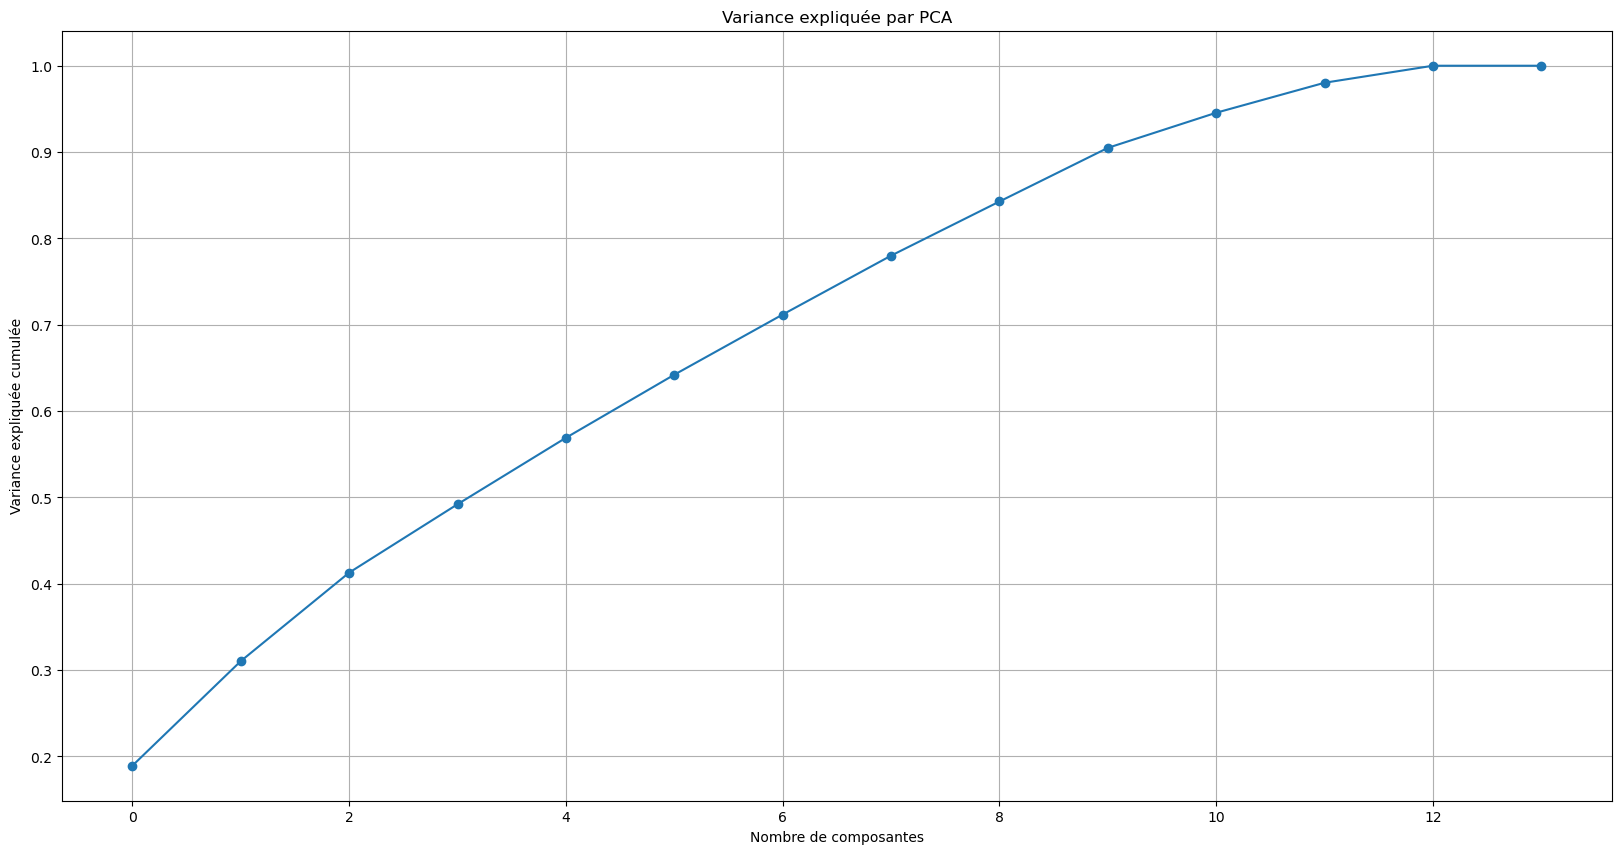

In [14]:
pca = PCA()
pca.fit(X_train_scale)  # X doit être centré-réduit !

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(20, 10))
plt.plot(cumulative_var, marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée par PCA")
plt.grid()
plt.show()

### Correlation Matrix

In [15]:
threshold = 0.8
col_corr = set()  # Ensemble des colonnes à supprimer
corr_matrix = X_train_df.corr()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            col_corr.add(colname)

print(f"Features à supprimer (corrélation > {threshold}) :")
print(col_corr)

# Supprimer les colonnes redondantes
df_reduced = X_train_df.drop(columns=col_corr)

Features à supprimer (corrélation > 0.8) :
set()


# Model

In [16]:
file_path = "./model/exploration.h5"

early_stop = EarlyStopping(monitor='loss', mode='min', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(file_path, monitor='loss', mode='min', save_best_only=True)

MyPath = Path("../logs/fit") / datetime.now().strftime("%Y%m%d-%H%M%S")

# Dossier de logs unique par session
log_dir = "logs/fit/" + datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=str(MyPath),
    histogram_freq=1,  # Log des histogrammes des poids
    write_graph=True,  # Visualisation du graphe du modèle
    write_images=True  # Affiche images d’entrée/sortie si applicable
)
callbacks = [early_stop, checkpoint, tensorboard_callback]
print("Chemin complet :", f"tensorboard --logdir={MyPath.resolve()}")

Chemin complet : tensorboard --logdir=/Users/forget/Desktop/Project_Momentum_AI/logs/fit/20260129-112008


In [17]:

def build_model(hp):
    n_hidden = hp.Int('n_hidden', min_value=1, max_value=15, step=1)
    n_neurons = hp.Int('n_neurons', min_value=16, max_value=512, step=8)
    learning_rate = hp.Float('learning_rate', min_value=1e-3, max_value=1e-1, sampling='log')

    optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd'])
    if optimizer_choice == "adam":
        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate, beta_1=0.9, beta_2=0.999,
            epsilon=1e-08, decay=0.0
        )
    else:
        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate, momentum=0.9, nesterov=True
        )

    model = keras.Sequential()
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=optimizer, 
        loss='mse',
        metrics=['mae', 'mse'])

    return model

In [18]:
random_search_tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    directory="Regression",
    project_name="Exploration_regression",
    seed=42
)

In [22]:
random_search_tuner.search(X_train_scale, y_train, epochs=500, callbacks=callbacks, validation_data=(X_val_scale, y_val), batch_size=32768)

Trial 5 Complete [00h 04m 07s]
val_loss: 0.012476161122322083

Best val_loss So Far: 0.012116357684135437
Total elapsed time: 00h 21m 52s


### Prédiction


In [23]:
best_model = random_search_tuner.get_best_models(num_models=1)[0]
best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]
predictions = best_model.predict(X_test_scale)

print("Meilleurs hyperparamètres :")
print(best_hps.values)
print(f'Prédiction of test: {predictions}')

4805/4805 [==============================] - 2s 366us/step
Meilleurs hyperparamètres :
{'n_hidden': 14, 'n_neurons': 56, 'learning_rate': 0.08547485565344061, 'optimizer': 'adam'}
Prédiction of test: [[0.09400629]
 [0.07125346]
 [0.0772979 ]
 ...
 [0.00489828]
 [0.22884862]
 [0.02206513]]


# Evaluation

### MAE & MSE

In [24]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print(f"MAE (Erreur Moyenne) : {mae:.4f}")
print(f"MSE (Erreur Quadratique) : {mse:.4f}")
print(f"RMSE (Écart type de l'erreur) : {rmse:.4f}")

MAE (Erreur Moyenne) : 0.1127
MSE (Erreur Quadratique) : 0.0248
RMSE (Écart type de l'erreur) : 0.1575


### Accuracy

In [31]:
predictions_reshape = predictions.reshape(-1, )
correct_direction = np.sign(y_test) == np.sign(predictions_reshape)
accuracy = np.mean(correct_direction) * 100

print(f"Directional Accuracy : {accuracy:.2f}%")

Directional Accuracy : 67.17%


### Accuracy sup 50%

In [40]:
predictions_reshape_sup50 = predictions_reshape[predictions_reshape > 0.5]
y_test_sup50 = y_test[y_test > 0.5]

print(y_test_sup50.shape, predictions_reshape_sup50.shape)

(2123,) (102,)


In [80]:
y_test

647560    0.177747
647561    0.126919
647562    0.089038
647563   -0.006504
647564    0.042861
            ...   
803273    0.009618
803274   -0.239177
803275    0.013105
803276   -0.053192
803277   -0.163629
Name: Target, Length: 153745, dtype: float64

# Backtesting

In [184]:
class Backtester:
    def __init__(self, data, start_date, initial_capital=1000, save_month=0, fee_per_trade=0, leverage=1.0, top=None):
        self.data = data.copy()
        self.initial_capital = initial_capital
        self.save_month = save_month
        self.fee_per_trade = fee_per_trade
        self.leverage = leverage
        self.top = top
        self.start_date = start_date

        self.Prediction()
        self._prepare_data()
        self._reset_state()


    def Prediction(self):
        self.data = self.data[self.data['Date'] >= self.start_date]
        test = self.data.drop(columns=['Ticker', 'Date', 'Low', 'High', 'Open', 'Close', 'Return'])
        print(test)
        scaler = StandardScaler()
        test_scale = scaler.fit_transform(test)
        self.data['Proba'] = best_model.predict(test_scale)

    def _prepare_data(self):
        self.df = self.data[["Date", "Ticker", "Close", "Proba", "Return"]] \
            .sort_values(["Date", "Ticker"]) \
            .copy()

        self.df['Date'] = pd.to_datetime(self.df['Date'])
        self.df[f'ma_12'] = self.df.groupby('Ticker')['Close']\
                .rolling(window=12, min_periods=1).mean().reset_index(level=0, drop=True)
        self.df[f'ma_50'] = self.df.groupby('Ticker')['Close']\
                .rolling(window=50, min_periods=1).mean().reset_index(level=0, drop=True)

        if self.top is not None:

            ranks = self.df.groupby('Date')['Proba'].rank(method='first', ascending=False)
            self.df['Prediction'] = ranks.apply(lambda x: 1 if x <= self.top else 0)

        self.df["BuySignal"] = (self.df["Prediction"] == 1) & (self.df['ma_50'] < self.df['ma_12'])
        self.df["SellSignal"] = (self.df["Prediction"] == 0)
        self.df["NextReturn"] = self.df.groupby("Ticker")["Return"].shift(-1)
        self.unique_dates = self.df["Date"].drop_duplicates().sort_values().to_numpy()

    def _reset_state(self):
        self.capital = self.initial_capital
        self.prev_holdings = set()

        self.portfolio_values = []
        self.returns = []
        self.position_count = []
        self.fee_history = []
        self.ticker_history = {}
        self.mean_return_history = []

    def _process_day(self, day, date):
        # Ajout du capital mensuel (épargne)
        self.capital += self.save_month

        buy_set = set(day.loc[day["BuySignal"], "Ticker"])

        current_portfolio = buy_set

        # Frais
        opened = current_portfolio - self.prev_holdings
        closed = self.prev_holdings - current_portfolio
        trades = len(opened) + len(closed)
        fees = trades * self.fee_per_trade
        self.capital = max(0, self.capital - fees)

        # Calcul rendement t+1
        r = day.loc[day["Ticker"].isin(current_portfolio), "NextReturn"].dropna().to_numpy()
        l = day.loc[day["Ticker"].isin(current_portfolio), ["Ticker", "NextReturn", "Proba"]]

        # Construction du dictionnaire : { 'Ticker': {'Return': ..., 'Prediction': ...} }
        tickers_info = {
            row['Ticker']: {
                'Return': row['NextReturn'],
                'Prediction': row['Proba']
            }
            for _, row in l.iterrows()
        }

        self.ticker_history[date] = tickers_info

        mean_return = np.mean(r) * self.leverage if len(r) > 0 else 0
        self.capital *= (1 + mean_return)

        # Historique
        self.portfolio_values.append(self.capital)
        self.returns.append(mean_return)
        self.position_count.append(len(current_portfolio))
        self.fee_history.append(fees)
        self.ticker_history[date] = l
        self.mean_return_history.append(mean_return)

        self.prev_holdings = current_portfolio

    def run(self):
        self._reset_state()

        for date in self.unique_dates:
            day = self.df.loc[self.df["Date"] == date]
            self._process_day(day, date)

        # Résultats journaliers
        self.performance = pd.DataFrame({
            "Date": self.unique_dates,
            "Capital": self.portfolio_values,
            "Return": np.array(self.returns),
            "Ticker_Count": self.position_count,
            "Fees": self.fee_history,
            "Return_Mean": self.mean_return_history,
        }).set_index("Date")

        return self.performance

    def summary(self):
        final_capital = self.portfolio_values[-1]
        total_return = (final_capital / self.initial_capital) - 1
        avg_positions = np.mean(self.position_count)

        # --- Durée totale ---
        start = pd.to_datetime(self.performance.index[0])
        end = pd.to_datetime(self.performance.index[-1])
        n_years = (end - start).days / 365

        # --- CAGR ---
        cagr = (final_capital / self.initial_capital) ** (1 / n_years) - 1

        # --- Sharpe Ratio (hebdomadaire) ---
        risk_free_annual = 0.03
        risk_free_weekly = (1 + risk_free_annual) ** (1 / 52) - 1

        weekly_returns = np.array(self.returns)
        excess_returns = weekly_returns - risk_free_weekly

        sharpe_ratio = (
            np.mean(excess_returns) / np.std(excess_returns) * np.sqrt(52)
            if np.std(excess_returns) > 0 else np.nan
        )

        # --- Max Drawdown ---
        capital_series = pd.Series(self.portfolio_values, index=self.performance.index)
        running_max = capital_series.cummax()
        drawdowns = (capital_series / running_max) - 1
        max_drawdown = drawdowns.min()  # Négatif, ex: -0.25 => -25%

        return {
            "Initial Capital": round(self.initial_capital, 2),
            "Final Capital": round(final_capital, 2),
            "Total Return %": round(total_return * 100, 2),
            "CAGR %": round(cagr * 100, 2),
            "Sharpe Ratio": round(sharpe_ratio, 2),
            "Max Drawdown %": round(max_drawdown * 100, 2),
            "Avg Positions Held": round(avg_positions, 2),
            "Total Fees Paid": round(sum(self.fee_history), 2),
            "Period (years)": round(n_years, 2)
        }

In [158]:
daily_data_test = pd.DataFrame()
data_SP500 = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_SP500.parquet')
#ata_NDX = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_NASDAQ.parquet')
#data_MidCap = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_MidCap_US.parquet')
#data_SmallCap = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_SmallCap_US.parquet')
data_MP = pd.read_parquet('/Users/forget/Library/Mobile Documents/com~apple~CloudDocs/Project Stock Market Deep Learning/Data/data_MP.parquet')
#daily_data_test = pd.concat([data_SP500, data_NDX, data_MidCap, data_SmallCap, data_MP], ignore_index=True)
daily_data_test = pd.concat([data_SP500, data_MP], ignore_index=True)
daily_data_test = daily_data_test.drop_duplicates(subset=['Ticker', 'Date'])
daily_data_test = daily_data_test.drop(columns='Adj Close')
daily_data_test

Price,Date,Close,High,Low,Open,Volume,Ticker
0,1976-07-01,0.385818,0.391612,0.385818,0.386977,344359.0,ETN
1,1976-07-01,0.109001,0.112029,0.109001,0.109001,2073600.0,MDT
2,1976-07-01,0.433622,0.441881,0.429492,0.433622,23970.0,DTE
3,1976-07-01,0.400973,0.406081,0.400973,0.400973,79200.0,EIX
4,1976-07-01,0.113854,0.117365,0.113854,0.117365,2615606.0,PFE
...,...,...,...,...,...,...,...
3881998,2025-11-28,558.599976,558.599976,556.150024,557.000000,64.0,GD=F
3881999,2025-12-01,558.349976,558.950012,557.099976,557.099976,55.0,GD=F
3882000,2025-12-02,554.700012,554.700012,554.700012,554.700012,1.0,GD=F
3882001,2025-12-03,556.700012,556.700012,556.700012,556.700012,0.0,GD=F


In [159]:
# Exemple avec daily_data
resampler = OHLCResampler(daily_data_test)
# Period
df = resampler.resample('W')

TICKER_TO_ID = {ticker: i + 1 for i, ticker in enumerate(df['Ticker'].unique())}
df['Ticker_ID'] = df['Ticker'].map(TICKER_TO_ID)

liste_ma = [12, 50]
liste_days = [4, 12, 25, 50]
liste_months = [1, 3, 6, 12]


features = Configuration_Features(data)
features.return_()
features.moving_average(window=liste_ma)
features.distance_moving_average(window=liste_ma)
features.performance(window=liste_months)
features.volume(window=liste_months)
features.date_numeric()
features.cleaning()
df_features = features.get_dataframe()

/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_2124/695107420.py:54: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.data_perf_fixed[col_name] = self.data_perf_fixed.groupby('Ticker')['Close'].pct_change(periods=w)
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_2124/695107420.py:54: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  self.data_perf_fixed[col_name] = self.data_perf_fixed.groupby('Ticker')['Close'].pct_change(periods=w)
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_2124/695107420.py:54: FutureWarning: The default fill_method='ffi

### Metrics

In [189]:
bt = Backtester(data=df_features, start_date='2010', initial_capital=10000, top=9, fee_per_trade=1, save_month=0)
results = bt.run()
metrics = bt.summary()
ti_history = bt.ticker_history

          Target  Ticker_ID  distance_ma_12/50  performance_short  \
417785  0.017717         69           3.230020           0.036382   
417786  0.005231        207           5.764622           0.038204   
417787 -0.043895        116           3.576990          -0.099005   
417788  0.126991         54           1.156567           0.123762   
417789  0.109302        109           1.142237           0.109952   
...          ...        ...                ...                ...   
803273  0.009618        456          10.311244           0.137492   
803274 -0.239177        390          19.877367           0.140726   
803275  0.013105        259           2.891493           0.004881   
803276 -0.053192        368          70.869442           0.392637   
803277 -0.163629        422          15.130678           0.017004   

        performance_medium_short  performance_medium_long  performance_long  \
417785                  0.062878                 0.276021          0.292716   
417786       

In [190]:
metrics

{'Initial Capital': 10000,
 'Final Capital': 2046240.31,
 'Total Return %': 20362.4,
 'CAGR %': 39.75,
 'Sharpe Ratio': 1.2,
 'Max Drawdown %': -33.33,
 'Avg Positions Held': 7.52,
 'Total Fees Paid': 2207,
 'Period (years)': 15.9}

In [191]:
ti_history.items()

dict_items([(numpy.datetime64('2010-01-03T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-01-10T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-01-17T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-01-24T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-01-31T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-02-07T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-02-14T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-02-21T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2010-02-28T00:00:00.000000000'), 

In [163]:
results.sort_values(by=['Return'], ascending=True, inplace=True)
results.head(50)

,Capital,Return,Ticker_Count,Fees,Return_Mean
Date,,,,,
2021-03-21,26162.205939,-0.258368,5,0,-0.258368
2022-06-12,29157.593777,-0.166479,4,0,-0.166479
2025-03-30,92942.925903,-0.145530,3,0,-0.145530
2024-04-14,69271.530050,-0.133647,5,0,-0.133647
2025-02-23,121907.975641,-0.129937,5,0,-0.129937
2023-12-31,57581.291386,-0.126021,2,4,-0.126021
2025-02-16,140114.044166,-0.119704,5,0,-0.119704
2020-03-29,8862.897871,-0.113356,4,4,-0.113356
2025-10-05,107555.411350,-0.110057,5,8,-0.110057


In [164]:
ti_history.items()

dict_items([(numpy.datetime64('2020-01-05T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-01-12T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-01-19T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-01-26T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-02-02T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-02-09T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-02-16T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-02-23T00:00:00.000000000'), Empty DataFrame
Columns: [Ticker, NextReturn, Proba]
Index: []), (numpy.datetime64('2020-03-01T00:00:00.000000000'), 

In [165]:
# 1. On crée une liste pour stocker chaque petit dataframe modifié
frames = []

for date, df_day in ti_history.items():
    # On travaille sur une copie pour ne pas modifier l'original
    temp_df = df_day.copy()
    
    # On ajoute la colonne Date qui n'était pas dans 'l'
    temp_df['Date'] = date
    
    # On l'ajoute à la liste
    frames.append(temp_df)

# 2. On colle tous les morceaux ensemble en une seule fois
history_trade = pd.concat(frames, ignore_index=True)

# 3. On renomme les colonnes pour avoir ce que tu voulais
history_trade = history_trade.rename(columns={
    "Ticker": "Tickers", 
    "NextReturn": "Returns", 
    "Proba": "Target"
})

# 4. Réorganisation des colonnes (optionnel)
history_trade = history_trade[["Date", "Tickers", "Returns", "Target"]]

print(history_trade.head())

        Date Tickers   Returns    Target
0 2020-03-29     GEN -0.033809  0.316931
1 2020-03-29    SHOP -0.151724  0.288530
2 2020-03-29    TSLA -0.066782  0.672198
3 2020-03-29       Z -0.201107  0.349565
4 2020-04-05    MRNA -0.085534  0.566601


In [156]:
history_trade[history_trade['Date'] < '2025-05-01'].sort_values(by='Date', ascending=False).head(50)

,Date,Tickers,Returns,Target
1389,2025-04-27,HII,0.017562,0.200532
1388,2025-04-27,EXE,0.005508,0.162089
1387,2025-04-27,EQT,0.032046,0.164926
1386,2025-04-27,ED,-0.003803,0.223604
1385,2025-04-27,DG,-0.034844,0.224595
1384,2025-04-20,HII,0.029934,0.198820
1383,2025-04-20,EXE,-0.010989,0.162064
1382,2025-04-20,EQT,-0.014515,0.164766
1381,2025-04-20,ED,-0.014719,0.224013
1380,2025-04-20,DG,0.005265,0.223512
